In [31]:
import torch
import torch.nn as nn

In [16]:
torch.set_printoptions(sci_mode=False)

In [2]:
inputs = torch.rand(2, 5)
inputs

tensor([[0.9065, 1.0000, 0.1710, 0.1919, 0.8093],
        [0.7700, 0.7771, 0.5762, 0.4555, 0.6685]])

In [8]:
# mean and variance
mean = inputs.mean(dim=1, keepdim=True)
variance = inputs.var(dim=1, keepdim=True)
mean, variance

(tensor([[0.6157],
         [0.6495]]),
 tensor([[0.1618],
         [0.0185]]))

In [11]:
torch.sqrt(variance)

tensor([[0.4022],
        [0.1362]])

In [12]:
normalised = (inputs - mean)/torch.sqrt(variance)

In [14]:
normalised

tensor([[ 0.7230,  0.9553, -1.1058, -1.0537,  0.4812],
        [ 0.8853,  0.9374, -0.5381, -1.4243,  0.1396]])

In [17]:
normalised.mean(dim=1, keepdim=True), normalised.var(dim=1, keepdim=True)

(tensor([[     0.0000],
         [    -0.0000]]),
 tensor([[1.0000],
         [1.0000]]))

In [23]:
def normalize_layer(layer):
    mean = layer.mean(dim=1, keepdim=True)
    variance = layer.var(dim=1, keepdim=True)
    normalised = (layer - mean) / torch.sqrt(variance)
    return normalised

In [24]:
normalize_layer(inputs)

tensor([[ 0.7230,  0.9553, -1.1058, -1.0537,  0.4812],
        [ 0.8853,  0.9374, -0.5381, -1.4243,  0.1396]])

In [34]:
nn.Parameter(torch.ones(4))

Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)

In [45]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        # eps is a small quantity to avoid division by zero incase variance becomes 0
        self.eps = 1e-5 
        # scale and shift are trainable parameters to improve layer normalisation
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [46]:
ln = LayerNorm(3)

In [47]:
input_x = torch.rand(5, 3)

In [48]:
input_x

tensor([[0.2900, 0.9583, 0.3685],
        [0.4883, 0.7255, 0.9493],
        [0.1423, 0.8359, 0.2756],
        [0.7689, 0.5987, 0.6110],
        [0.9023, 0.7560, 0.3772]])

In [49]:
output = ln.forward(input_x)

In [58]:
output.mean(dim=1, keepdim=True)

tensor([[    -0.0000],
        [     0.0000],
        [    -0.0000],
        [     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)

In [50]:
output.var(dim=1, keepdim=True)

tensor([[0.9999],
        [0.9998],
        [0.9999],
        [0.9989],
        [0.9999]], grad_fn=<VarBackward0>)

In [64]:
# sample neural network layer without normalisaton
torch.manual_seed(123)
input_example = torch.rand(2, 5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(input_example)
out.mean(dim=1, keepdim=True), out.var(dim=1, keepdim=True)

(tensor([[0.2432],
         [0.1928]], grad_fn=<MeanBackward1>),
 tensor([[0.0799],
         [0.0670]], grad_fn=<VarBackward0>))

In [66]:
import numpy as np

In [106]:
series = np.random.rand(1000)

In [107]:
series

array([9.65350179e-01, 1.27971792e-02, 7.70865654e-01, 4.20745284e-01,
       3.83860951e-01, 7.56246149e-01, 1.81081550e-01, 6.82099243e-01,
       3.06703132e-01, 9.40364327e-01, 8.09847576e-01, 5.92400001e-04,
       4.05904341e-01, 8.27425878e-01, 8.38165058e-01, 2.26903264e-01,
       1.23874266e-01, 8.94469342e-02, 7.44909787e-01, 9.49808301e-01,
       7.39331867e-01, 1.95037130e-01, 7.64703008e-01, 3.49151900e-01,
       7.54268704e-01, 9.03061898e-01, 9.52518162e-01, 2.20088130e-02,
       7.97593199e-01, 4.35902875e-02, 3.26107298e-01, 8.74215398e-01,
       4.10058111e-01, 4.74628762e-01, 5.56438429e-01, 9.78879527e-01,
       6.27590498e-01, 4.43866064e-01, 2.87668307e-01, 9.35287423e-01,
       4.78819547e-01, 2.77692832e-01, 1.53600227e-01, 6.41955514e-01,
       8.52498179e-01, 4.03065993e-01, 4.70550954e-01, 7.79811359e-01,
       6.57326482e-01, 6.92939815e-01, 7.71644279e-01, 1.10061081e-01,
       5.76545504e-01, 2.41544330e-01, 6.47666543e-01, 3.52211818e-01,
      

In [108]:
# mean and variance
series.mean(), series.var()

(0.4986842228415129, 0.08553116278006472)

In [109]:
series_norm = (series - series.mean())/np.sqrt(series.var())

In [110]:
series_norm.mean(), series_norm.var()

(-5.551115123125783e-18, 1.0)

In [111]:
import matplotlib.pyplot as plt

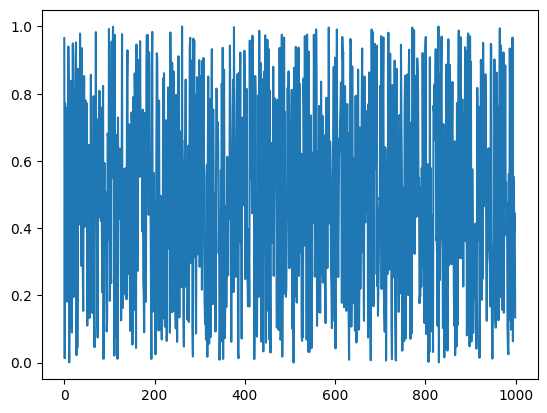

In [112]:
plt.plot(series)

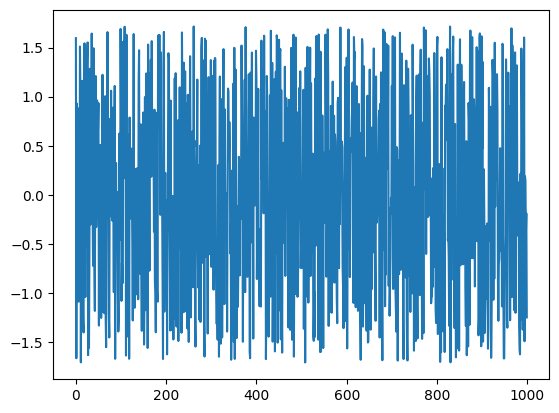

In [113]:
plt.plot(series_norm)